# Plant keypoint pipeline — QC notebook

This notebook is **only for visual QC**. The actual pipeline (build videos → create project →
extract → label → train → evaluate → analyze → postprocess) is driven from the terminal, which is
robust for long training runs and for launching the labeling GUI:

```powershell
# run from the repo root, using the dedicated DLC env
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints gpu-check
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints build-videos
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints create-project
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints extract
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints label        # GUI: click base + meristem
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints check-labels
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints train
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints evaluate
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints analyze
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints postprocess --monotonic
```

**Kernel:** select `microneedle (dlc keypoints)`.

Keypoints: `base` = stem at the soil line; `meristem` = apical growth tip (estimated even when occluded).

In [1]:
import sys
from pathlib import Path

# make the repo importable when running from notebooks/
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'plant_timelapse').is_dir():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from plant_timelapse.keypoints import config as C
from plant_timelapse.keypoints import frame_export, frame_select, postprocess

print('repo root:', REPO_ROOT)
print('datasets :', list(C.DATASETS))
print('DLC dir  :', C.DLC_DIR)

repo root: c:\Users\ryank\Code\microneedle_IAA_Raman_analysis
datasets : ['run4', 'run5']
DLC dir  : C:\Users\ryank\Code\microneedle_IAA_Raman_analysis\plant_timelapse\dlc


## GPU check

In [2]:
import torch
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0), '| cuda', torch.version.cuda)

torch 2.12.1+cu126 | cuda available: True
device: NVIDIA GeForce RTX 3070 Laptop GPU | cuda 12.6


## Preview a prepared frame (absolute 8-bit + ROI crop)

Confirms the model sees the same appearance/coordinate frame as the segmentation pipeline.

run4 -> 325 frames


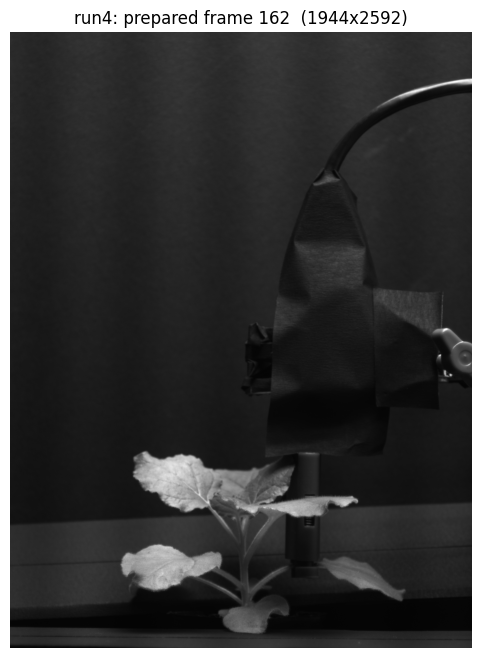

day/night split: {'day': 216, 'night': 109, 'untimed': 0, 'total': 325}


In [3]:
name, ddir = next(C.dataset_items())
tiffs = frame_export.list_tiffs(ddir)
print(name, '->', len(tiffs), 'frames')

sample = frame_export.prepare_frame(tiffs[len(tiffs) // 2])
plt.figure(figsize=(6, 8))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f'{name}: prepared frame {len(tiffs) // 2}  ({sample.shape[1]}x{sample.shape[0]})')
plt.axis('off')
plt.show()

print('day/night split:', frame_select.summarize_day_night(tiffs))

## Stem-height curve (after `analyze` + `postprocess`)

Reads the CSV written by the `postprocess` command and plots raw vs smoothed height with confidence.

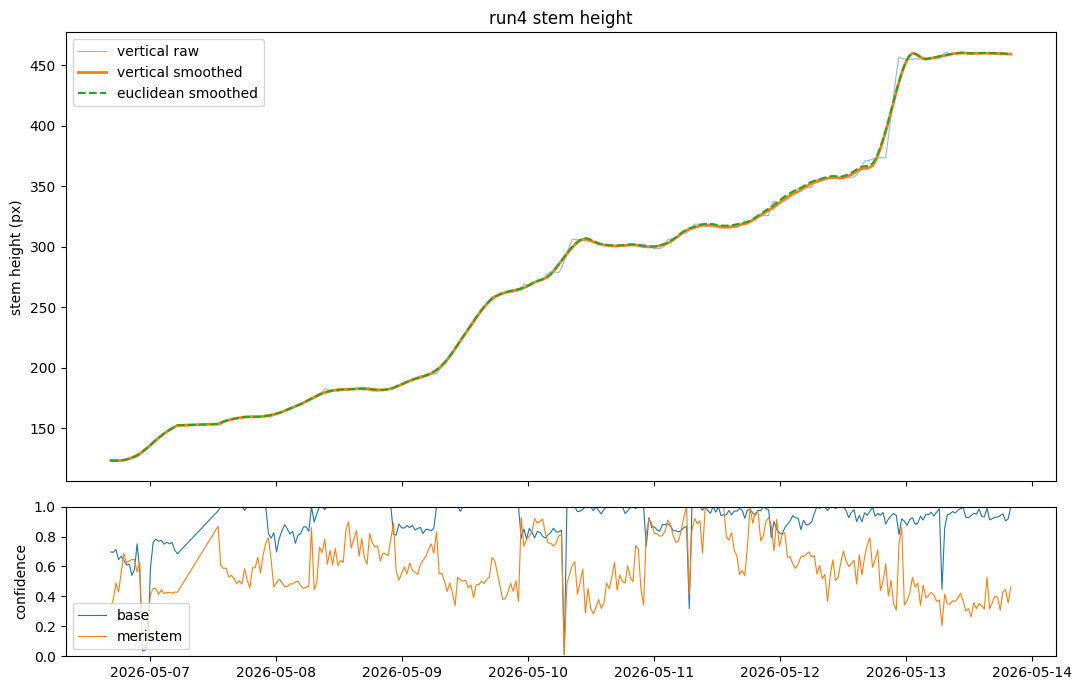

In [54]:
DATASET = 'run4'  # change as needed
csv_path = C.DLC_DIR / f'stem_height_{DATASET}.csv'
assert csv_path.exists(), f'Not found: {csv_path}. Run analyze + postprocess first.'
df = pd.read_csv(csv_path)
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

x = df['timestamp'] if 'timestamp' in df.columns and df['timestamp'].notna().any() else df['frame']
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[3, 1])
ax[0].plot(x, df['height_px'], lw=0.8, alpha=0.5, label='vertical raw')
ax[0].plot(x, df['height_smooth'], lw=2, label='vertical smoothed')
if 'height_eucl_smooth' in df.columns:
    ax[0].plot(x, df['height_eucl_smooth'], lw=1.5, ls='--', label='euclidean smoothed')
if 'height_monotonic' in df.columns:
    ax[0].plot(x, df['height_monotonic'], lw=1.5, ls=':', label='monotonic')
ax[0].set_ylabel('stem height (px)'); ax[0].legend(); ax[0].set_title(f'{DATASET} stem height')
ax[1].plot(x, df['base_likelihood'], lw=0.8, label='base')
ax[1].plot(x, df['meristem_likelihood'], lw=0.8, label='meristem')
ax[1].set_ylabel('confidence'); ax[1].set_ylim(0, 1); ax[1].legend()
plt.tight_layout(); plt.show()

## Base vs meristem contribution (raw vs interpolated)

`height = base_y - meristem_y`. Solid lines are **raw DLC** coordinates; dashed lines are **interpolated** (`*_interp`) after low-confidence frames are cleaned.

Compare how much each keypoint moves before vs after interpolation, and how that affects the height curve (`height_px_raw` vs `height_px`).

Frame-to-frame |Δ| (mean / max px):
  base_y raw              0.31 /    6.8
  base_y interp           0.29 /    4.2
  base_y refined          0.29 /    4.2
  meristem_y raw         17.93 / 1047.5
  meristem_y interp       2.14 /   51.2
  meristem_y refined      0.85 /   11.8
  height_px raw          18.04 / 1047.7
  height_px clean         1.01 /    9.2


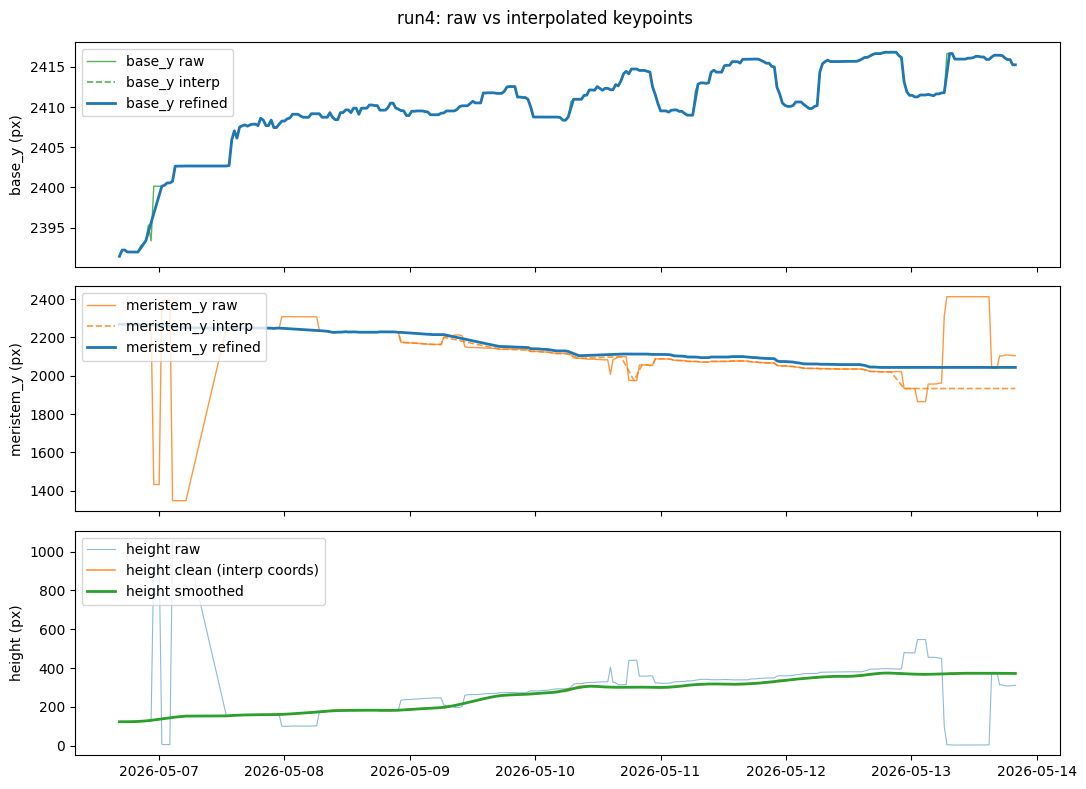

In [53]:
x = df['timestamp'] if 'timestamp' in df.columns and df['timestamp'].notna().any() else df['frame']

has_interp = 'base_y_interp' in df.columns and 'meristem_y_interp' in df.columns
has_refined = 'base_y_refined' in df.columns and 'meristem_y_refined' in df.columns

def _jump_stats(name, series):
    d = series.diff().abs()
    print(f"  {name:22s} {d.mean():5.2f} / {d.max():6.1f}")

print('Frame-to-frame |Δ| (mean / max px):')
_jump_stats('base_y raw', df['base_y'])
if has_interp:
    _jump_stats('base_y interp', df['base_y_interp'])
if has_refined:
    _jump_stats('base_y refined', df['base_y_refined'])
_jump_stats('meristem_y raw', df['meristem_y'])
if has_interp:
    _jump_stats('meristem_y interp', df['meristem_y_interp'])
if has_refined:
    _jump_stats('meristem_y refined', df['meristem_y_refined'])
if 'height_px_raw' in df.columns:
    _jump_stats('height_px raw', df['height_px_raw'])
else:
    _jump_stats('height_px raw*', df['base_y'] - df['meristem_y'])
_jump_stats('height_px clean', df['height_px'])

fig, ax = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

ax[0].plot(x, df['base_y'], lw=1.0, color='C2', alpha=0.8, label='base_y raw')
if has_interp:
    ax[0].plot(x, df['base_y_interp'], lw=1.2, ls='--', color='C2', alpha=0.8, label='base_y interp')
if has_refined:
    ax[0].plot(x, df['base_y_refined'], lw=2.0, color='C0', label='base_y refined')
ax[0].set_ylabel('base_y (px)')
ax[0].legend(loc='upper left')

ax[1].plot(x, df['meristem_y'], lw=1.0, color='C1', alpha=0.8, label='meristem_y raw')
if has_interp:
    ax[1].plot(x, df['meristem_y_interp'], lw=1.2, ls='--', color='C1', alpha=0.8, label='meristem_y interp')
if has_refined:
    ax[1].plot(x, df['meristem_y_refined'], lw=2.0, color='C0', label='meristem_y refined')
ax[1].set_ylabel('meristem_y (px)')
ax[1].legend(loc='upper left')

height_raw = df['height_px_raw'] if 'height_px_raw' in df.columns else df['base_y'] - df['meristem_y']
ax[2].plot(x, height_raw, lw=0.8, alpha=0.5, label='height raw')
ax[2].plot(x, df['height_px'], lw=1.2, alpha=0.8, label='height clean (interp coords)')
ax[2].plot(x, df['height_smooth'], lw=2, label='height smoothed')
ax[2].set_ylabel('height (px)')
ax[2].legend(loc='upper left')

fig.suptitle(f'{DATASET}: raw vs interpolated keypoints')
plt.tight_layout()
plt.show()

## Overlay predicted keypoints on a frame

Spot-check frames where the height curve wobbles.

1. Run the **suspicious frames** cell below — flags jumps/dips and prints a `--frames` list for re-labeling.
2. Set `VIDEO_FRAME` in the single-frame cell to inspect one image.
3. Run the **overlay video** cell to export an mp4 with base + meristem on every frame.

In [20]:
# Tune thresholds — lower JUMP_THRESHOLD_PX catches smaller wobbles (e.g. frames 95–105)
JUMP_THRESHOLD_PX = 3.0
MERISTEM_L_THRESH = 0.65
DIP_THRESHOLD_PX = 2.0
NEIGHBOR_PAD = 1  # include frames before/after each hit (for labeling context)

cols = ['frame', 'timestamp', 'height_px', 'height_smooth', 'meristem_likelihood', 'base_likelihood']
d_smooth = df['height_smooth'].diff()

flagged = df.assign(
    jump_smooth=d_smooth.abs(),
    dip=d_smooth,
)
flagged['reason'] = ''
for i, row in flagged.iterrows():
    reasons = []
    if row['jump_smooth'] >= JUMP_THRESHOLD_PX:
        reasons.append(f"jump={row['jump_smooth']:.1f}px")
    if row['dip'] < -DIP_THRESHOLD_PX:
        reasons.append(f"dip={row['dip']:.1f}px")
    if row['meristem_likelihood'] < MERISTEM_L_THRESH and row['jump_smooth'] >= 1.5:
        reasons.append(f"mer_l={row['meristem_likelihood']:.2f}")
    flagged.at[i, 'reason'] = '; '.join(reasons)

hits = flagged[flagged['reason'] != ''].copy()

# Table: all flagged frames, largest jumps first
suspicious = hits[cols + ['jump_smooth', 'reason']].sort_values(
    ['jump_smooth', 'frame'], ascending=[False, True]
)

# Frame list for Path B (+ neighbors); trim manually if too long
frame_min, frame_max = int(df['frame'].min()), int(df['frame'].max())
label_frames = sorted({
    int(f) + pad
    for f in hits['frame'].astype(int)
    for pad in range(-NEIGHBOR_PAD, NEIGHBOR_PAD + 1)
    if frame_min <= int(f) + pad <= frame_max
})
frames_csv = ','.join(str(f) for f in label_frames)

print(f'{len(hits)} flagged frame(s); {len(label_frames)} with ±{NEIGHBOR_PAD} neighbor(s) for labeling.')
print()
print('Copy for Path B CLI:')
print(
    f'.venv-dlc\\Scripts\\python.exe -m plant_timelapse.keypoints add-label-frames {DATASET} --frames {frames_csv}'
)
print()
print('Frame list only:')
print(frames_csv)

suspicious

93 flagged frame(s); 113 with ±1 neighbor(s) for labeling.

Copy for Path B CLI:
.venv-dlc\Scripts\python.exe -m plant_timelapse.keypoints add-label-frames run4 --frames 12,13,14,15,16,17,18,19,20,21,81,82,83,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,155,156,157,158,159,160,161,162,163,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,197,198,199,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288

Frame list only:
12,13,14,15,16,17,18,19,20,21,81,82,83,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,155,156,157,158,159,160,161,162,163,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,197,198,199,272,273,274,275,276,277,278,27

,frame,timestamp,height_px,height_smooth,meristem_likelihood,base_likelihood,jump_smooth,reason
187,187,2026-05-10 22:28:11,358.717529,347.583891,0.822379,0.735042,10.455397,jump=10.5px; dip=-10.5px
186,186,2026-05-10 21:57:46,358.522135,358.039288,0.342031,1.000000,10.447807,jump=10.4px; dip=-10.4px; mer_l=0.34
173,173,2026-05-10 15:25:00,314.547054,330.562106,0.451316,1.000000,9.834639,jump=9.8px; mer_l=0.45
188,188,2026-05-10 22:59:03,323.458252,337.974011,0.916364,0.927384,9.609880,jump=9.6px; dip=-9.6px
174,174,2026-05-10 15:55:12,314.133757,340.062798,0.530322,1.000000,9.500692,jump=9.5px; mer_l=0.53
...,...,...,...,...,...,...,...,...
19,19,2026-05-07 02:07:24,142.700979,143.057759,0.444385,0.775615,1.631212,mer_l=0.44
130,130,2026-05-09 17:36:59,272.845459,271.563094,0.636770,1.000000,1.607110,mer_l=0.64
13,13,2026-05-06 23:02:44,133.377711,133.007213,0.059825,0.038876,1.581849,mer_l=0.06
162,162,2026-05-10 09:52:39,319.093327,318.276993,0.493777,0.970745,1.569503,mer_l=0.49


frame 324: base raw=(992,2415)  interp=(992,2415)  mer raw=(967,2105)  interp=(981,1933)  final=(981,1956) (base_final_y=2415)


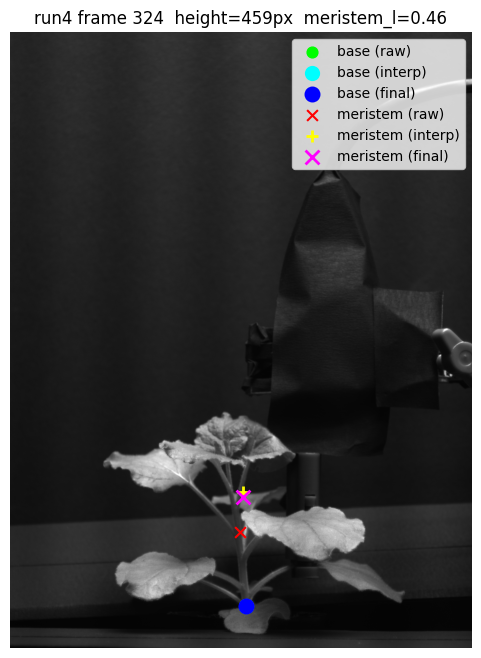

In [55]:
# Pick ONE: set VIDEO_FRAME (preferred) or ROW (df row index). Leave the other as None.
VIDEO_FRAME = 324   # e.g. from the `frame` column in the table above
ROW = None

if VIDEO_FRAME is not None:
    row = df.loc[df['frame'] == VIDEO_FRAME].iloc[0]
else:
    row = df.iloc[ROW if ROW is not None else len(df) // 2]

tiffs = frame_export.list_tiffs(dict(C.DATASETS)[DATASET])
img = frame_export.prepare_frame(tiffs[int(row['frame'])])
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ROI=None -> full frame; coordinates in the CSV are already full-frame pixels.
x0, y0 = (C.ROI[0], C.ROI[1]) if C.ROI is not None else (0, 0)

plt.figure(figsize=(6, 8))
plt.imshow(rgb)

plt.scatter([row['base_x'] - x0], [row['base_y'] - y0], c='lime', s=60, marker='o', label='base (raw)')
if 'base_x_interp' in row.index:
    plt.scatter(
        [row['base_x_interp'] - x0], [row['base_y_interp'] - y0],
        c='cyan', s=80, marker='o', facecolors='none', linewidths=2, label='base (interp)',
    )
if 'base_y_refined' in row.index:
    bx_final = row['base_x_interp'] if 'base_x_interp' in row.index else row['base_x']
    plt.scatter(
        [bx_final - x0], [row['base_y_refined'] - y0],
        c='blue', s=90, marker='o', linewidths=2, label='base (final)',
    )

plt.scatter([row['meristem_x'] - x0], [row['meristem_y'] - y0], c='red', s=60, marker='x', label='meristem (raw)')
if 'meristem_y_interp' in row.index:
    plt.scatter(
        [row['meristem_x_interp'] - x0], [row['meristem_y_interp'] - y0],
        c='yellow', s=80, marker='+', linewidths=2, label='meristem (interp)',
    )

if 'meristem_y_refined' in row.index:
    mx_final = row['meristem_x_interp'] if 'meristem_x_interp' in row.index else row['meristem_x']
    plt.scatter(
        [mx_final - x0], [row['meristem_y_refined'] - y0],
        c='magenta', s=100, marker='x', linewidths=2, label='meristem (final)',
    )

    # Debug printout
    msg = (
        f"frame {int(row['frame'])}: "
        f"base raw=({row['base_x']:.0f},{row['base_y']:.0f})  "
    )
    if 'base_y_interp' in row.index and 'base_y_interp' in row.index:
        if 'base_x_interp' in row.index:
            msg += f"interp=({row['base_x_interp']:.0f},{row['base_y_interp']:.0f})  "
    if 'meristem_y_interp' in row.index:
        msg += (
            f"mer raw=({row['meristem_x']:.0f},{row['meristem_y']:.0f})  "
            f"interp=({row['meristem_x_interp']:.0f},{row['meristem_y_interp']:.0f})  "
        )
    msg += (
        f"final=({mx_final:.0f},{row['meristem_y_refined']:.0f})"
        f" (base_final_y={row['base_y_refined']:.0f})"
    )
    print(msg)

plt.title(
    f"{DATASET} frame {int(row['frame'])}  "
    f"height={row['height_px']:.0f}px  "
    f"meristem_l={row['meristem_likelihood']:.2f}"
)
plt.legend(); plt.axis('off'); plt.show()

In [57]:
# Export full-stack QC video: base (green circle) + meristem (red cross) + stem line
import importlib
importlib.reload(frame_export)  # pick up new helpers without restarting kernel

OUT_FPS = 30  # playback speed; lower = slower review
OUT_PATH = C.DLC_DIR / f'{DATASET}_keypoints_overlay.mp4'

out, n, n_drawn = frame_export.export_keypoint_overlay_video(
    dict(C.DATASETS)[DATASET],
    df,
    OUT_PATH,
    fps=OUT_FPS,
    draw_stem_line=True,
    resize_factor=0.5,
)
print(f'Wrote {n} frames ({n_drawn} with overlays) -> {out}')

overlay -> run4_keypoints_overlay.mp4: 100%|██████████| 325/325 [01:11<00:00,  4.54frame/s]

Wrote 325 frames (325 with overlays) -> C:\Users\ryank\Code\microneedle_IAA_Raman_analysis\plant_timelapse\dlc\run4_keypoints_overlay.mp4
